<a href="https://colab.research.google.com/github/malakalnaaji-web/MK/blob/main/Churn_Analysis_MK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Data description**

**CustomerID**	Unique identifier assigned to each customer.

**Age**	Age of the customer (in years).

**Gender**	Customer’s gender (Male or Female).

**Tenure**	Total duration (in months) the customer has been associated with the company.

**Usage Frequency**	A measure of how often the customer engages with the service.

**Support Calls**	Total number of support calls made by the customer.

**Payment Delay**	Number of days by which the customer’s payment is overdue.

**Subscription Type**	The customer’s subscription tier (Basic, Standard, or Premium).

**Contract Length**	The duration of the customer's contract (Monthly, Quarterly, or Annual).

**Total Spend**	Cumulative amount spent by the customer throughout their tenure.

**Last Interaction**	Number of days since the customer’s last recorded interaction with the company.

**Churn**	Binary indicator of customer churn: - 1 - The customer has churned. - 0 - The customer remains active.







# **Import Libraries And load Data**





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.inspection import permutation_importance
!pip install shap
import shap


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df= pd.concat([
    pd.read_csv(r'/content/drive/MyDrive/Machine_Learning/customer_churn_dataset-training-master.csv'),
    pd.read_csv(r'/content/drive/MyDrive/Machine_Learning/customer_churn_dataset-testing-master.csv')
], axis=0)

In [ ]:
df.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


# **Exploratory Data Analysis (EDA)**

In [ ]:
df.shape


(505207, 12)

**Customer Engagement**

Tenure Groups (New vs. Long-Term Customers): Long-term customers may have lower churn, while new users are at higher risk.
Time Since Last Interaction (Captures recent engagement patterns)

Customers with long inactivity are more likely to churn.
Usage Frequency Decline (Detects users who reduce engagement over time)If a user’s frequency is below the median, flag them as at-risk.

Inactivity Ratio (How much time has passed since the last interaction?)If a customer hasn’t interacted for a long time, they might churn.

In [ ]:
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[0, 6, 12, 24, 60, 120], labels=['<6m', '6-12m', '1-2y', '2-5y', '5+ years'])


In [ ]:
df['Time_Since_Last_Interaction'] = df['Tenure'] - df['Last Interaction']


In [ ]:
df['Usage_Decline'] = (df['Usage Frequency'] < df['Usage Frequency'].median()).astype(int)


In [ ]:
df['Inactivity_Ratio'] = df['Last Interaction'] / df['Tenure']


**Financial & Payment Behavior**


In [ ]:
df['Payment_Delay_Rate'] = df['Payment Delay'] / (df['Tenure'] + 1)  # Avoid division by zero


In [ ]:
df['CLV'] = df['Total Spend'] / (df['Tenure'] + 1)


**Churn risk indicator**

In [ ]:
df['Low_Spend_High_Support'] = ((df['Total Spend'] < df['Total Spend'].median()) &
                                (df['Support Calls'] > df['Support Calls'].median())).astype(int)


In [ ]:
df.shape

(505207, 19)

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn',
       'Tenure_Group', 'Time_Since_Last_Interaction', 'Usage_Decline',
       'Inactivity_Ratio', 'Payment_Delay_Rate', 'CLV',
       'Low_Spend_High_Support'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505207 entries, 0 to 64373
Data columns (total 19 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   CustomerID                   505206 non-null  float64 
 1   Age                          505206 non-null  float64 
 2   Gender                       505206 non-null  object  
 3   Tenure                       505206 non-null  float64 
 4   Usage Frequency              505206 non-null  float64 
 5   Support Calls                505206 non-null  float64 
 6   Payment Delay                505206 non-null  float64 
 7   Subscription Type            505206 non-null  object  
 8   Contract Length              505206 non-null  object  
 9   Total Spend                  505206 non-null  float64 
 10  Last Interaction             505206 non-null  float64 
 11  Churn                        505206 non-null  float64 
 12  Tenure_Group                 505206 non-null  cate

In [ ]:
df.isnull().sum()


,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [ ]:
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):

            df[col].fillna(df[col].mean(), inplace=True)
        else:

            df[col].fillna(df[col].mode()[0], inplace=True)


<ipython-input-17-4a435bfbc45c>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
<ipython-input-17-4a435bfbc45c>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
df[df.duplicated()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Tenure_Group,Time_Since_Last_Interaction,Usage_Decline,Inactivity_Ratio,Payment_Delay_Rate,CLV,Low_Spend_High_Support


In [ ]:
df.drop_duplicates(inplace= True )

In [ ]:
df.shape

(505207, 19)

In [ ]:
df.drop(columns=['CustomerID'], inplace=True)


In [ ]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Time_Since_Last_Interaction,Usage_Decline,Inactivity_Ratio,Payment_Delay_Rate,CLV,Low_Spend_High_Support
count,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000,505207.000000
mean,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203,16.739855,0.489669,1.076737,0.795631,36.039656,0.264076
std,12.670564,17.237464,8.619314,3.133599,8.451179,245.319013,8.608278,0.496943,19.303763,0.499894,2.432142,1.363982,53.130634,0.440840
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000,-29.000000,0.000000,0.016667,0.000000,1.639344,0.000000
25%,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000,2.000000,0.000000,0.229167,0.196078,12.346050,0.000000
50%,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000,17.000000,0.000000,0.463415,0.408163,19.037917,0.000000
75%,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000,32.000000,1.000000,0.892857,0.777778,35.052632,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000,59.000000,1.000000,30.000000,15.000000,500.000000,1.000000


In [ ]:
df.describe(include='object')

,Gender,Subscription Type,Contract Length
count,505207,505207,505207
unique,2,3,3
top,Male,Standard,Annual
freq,280274,170631,198609


In [ ]:
print('GENDER')
print(df['Gender'].value_counts())
print('-------------------------------------')
print('SUBSCRIPTION TYPE')
print(df['Subscription Type'].value_counts())
print('-------------------------------------')
print('CONTRACT LENGTH')
print(df['Contract Length'].value_counts())


GENDER
Gender
Male      280274
Female    224933
Name: count, dtype: int64
-------------------------------------
SUBSCRIPTION TYPE
Subscription Type
Standard    170631
Premium     170099
Basic       164477
Name: count, dtype: int64
-------------------------------------
CONTRACT LENGTH
Contract Length
Annual       198609
Quarterly    197364
Monthly      109234
Name: count, dtype: int64


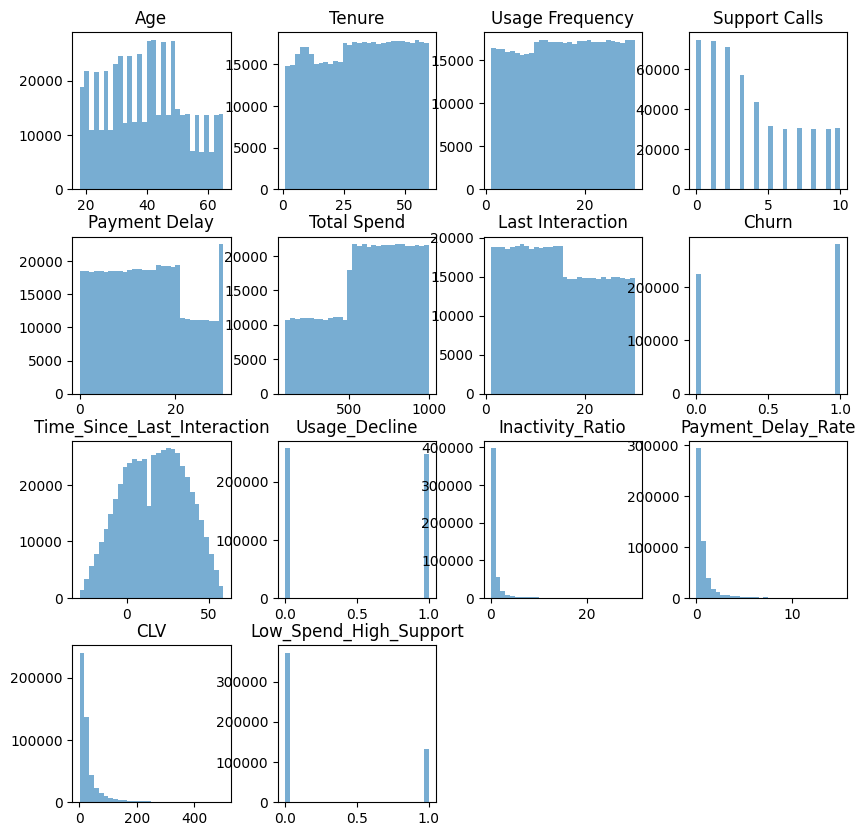

In [ ]:
df.hist(bins= 30, figsize= (10,10), alpha=0.6, grid=False)
plt.show()

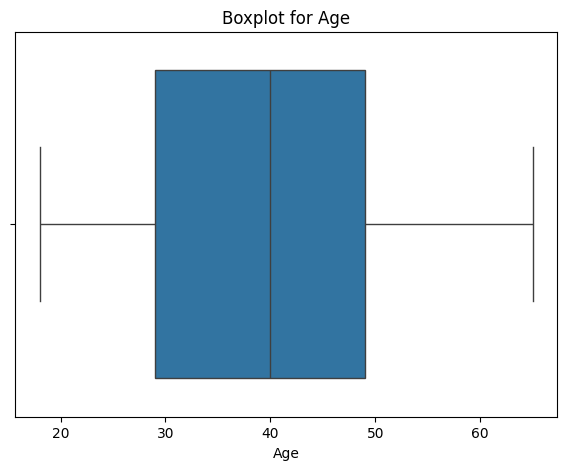

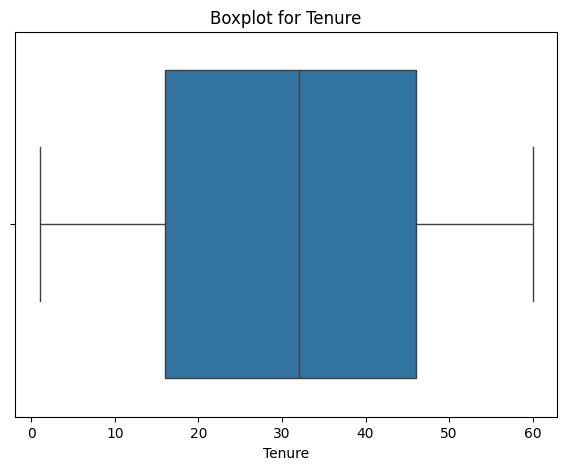

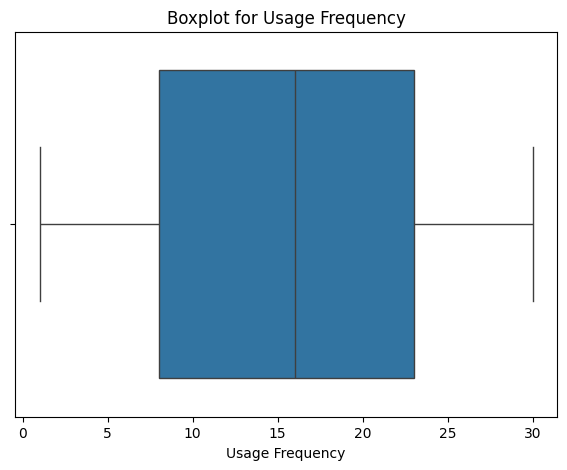

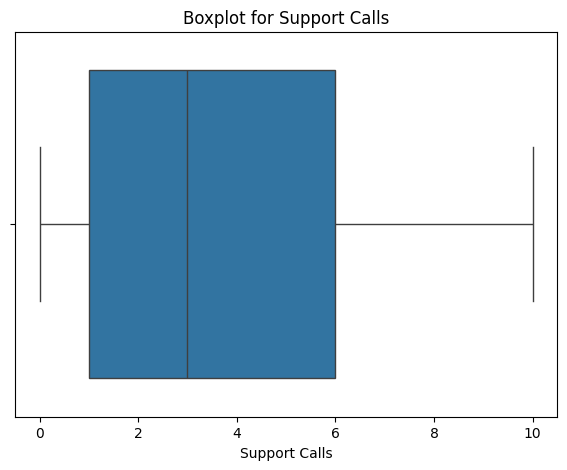

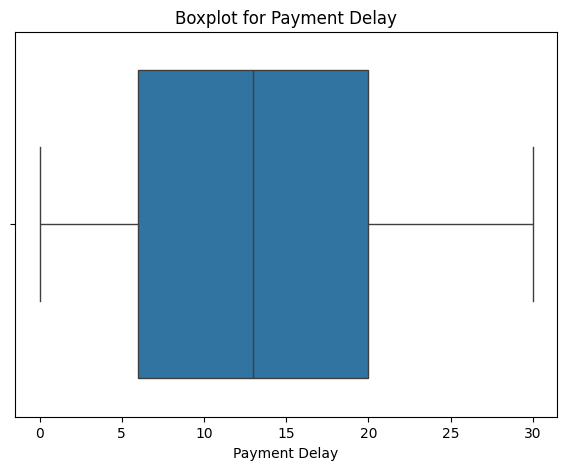

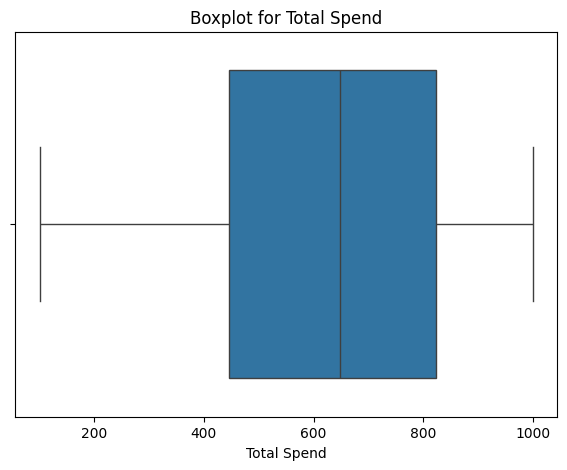

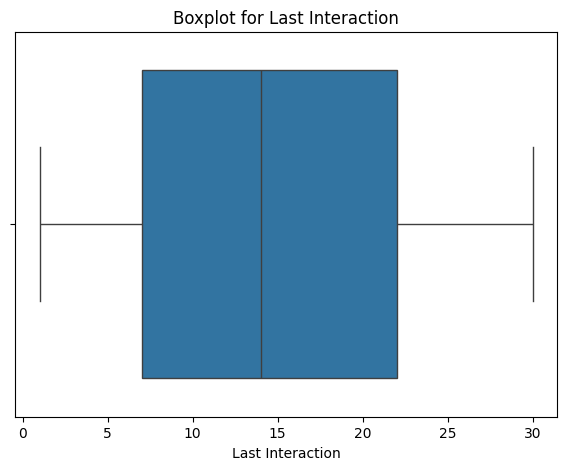

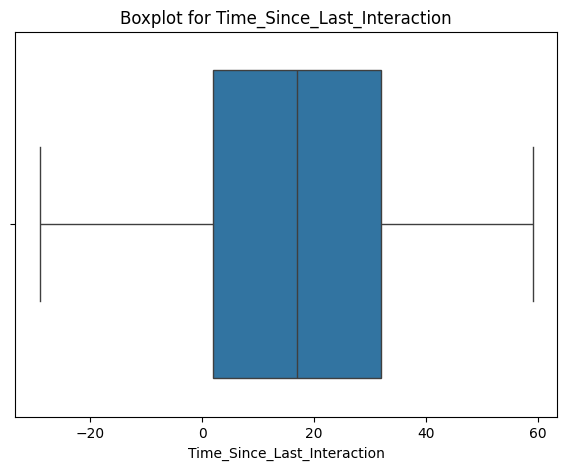

In [ ]:
numerical_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
                  'Total Spend', 'Last Interaction', 'Time_Since_Last_Interaction']

for c in numerical_cols:
    plt.figure(figsize=(7, 5))
    sns.boxplot(x=df[c])
    plt.title(f'Boxplot for {c}')
    plt.show()


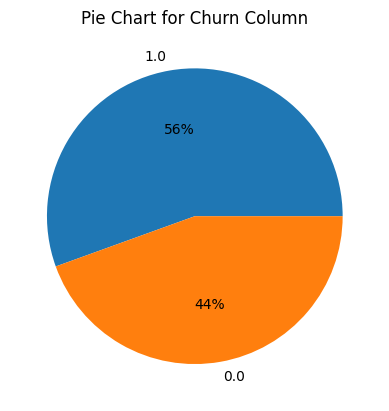

Customer that Churnd:  280492
Customer that Stayed:  224714


In [ ]:
df = df[df['Churn'].isin([0, 1])]
plt.pie(df['Churn'].value_counts(), labels = df['Churn'].value_counts().index, autopct='%.0f%%')
plt.title('Pie Chart for Churn Column')
plt.show()

print('Customer that Churnd: ', len(df[df['Churn']==1]))
print('Customer that Stayed: ',len(df[df['Churn']==0]))

inbalanced data in our target column. 56% (280492) of the customer left the company while 44% (224714) didn't leave.

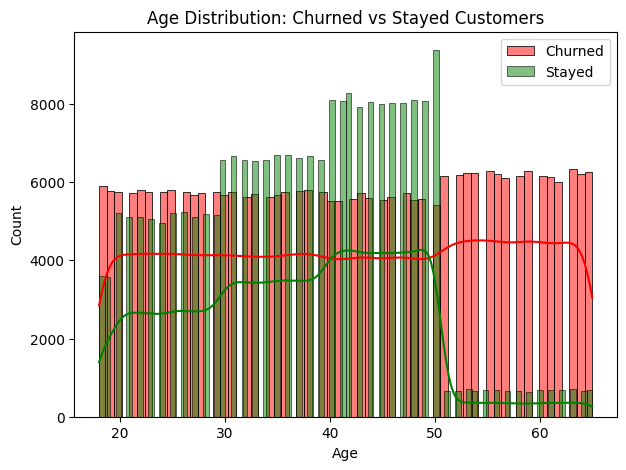

In [ ]:

plt.figure(figsize=(7, 5))
sns.histplot(df[df['Churn'] == 1]['Age'], color='red', label='Churned', kde=True)
sns.histplot(df[df['Churn'] == 0]['Age'], color='green', label='Stayed', kde=True)
plt.title('Age Distribution: Churned vs Stayed Customers')
plt.legend()
plt.show()


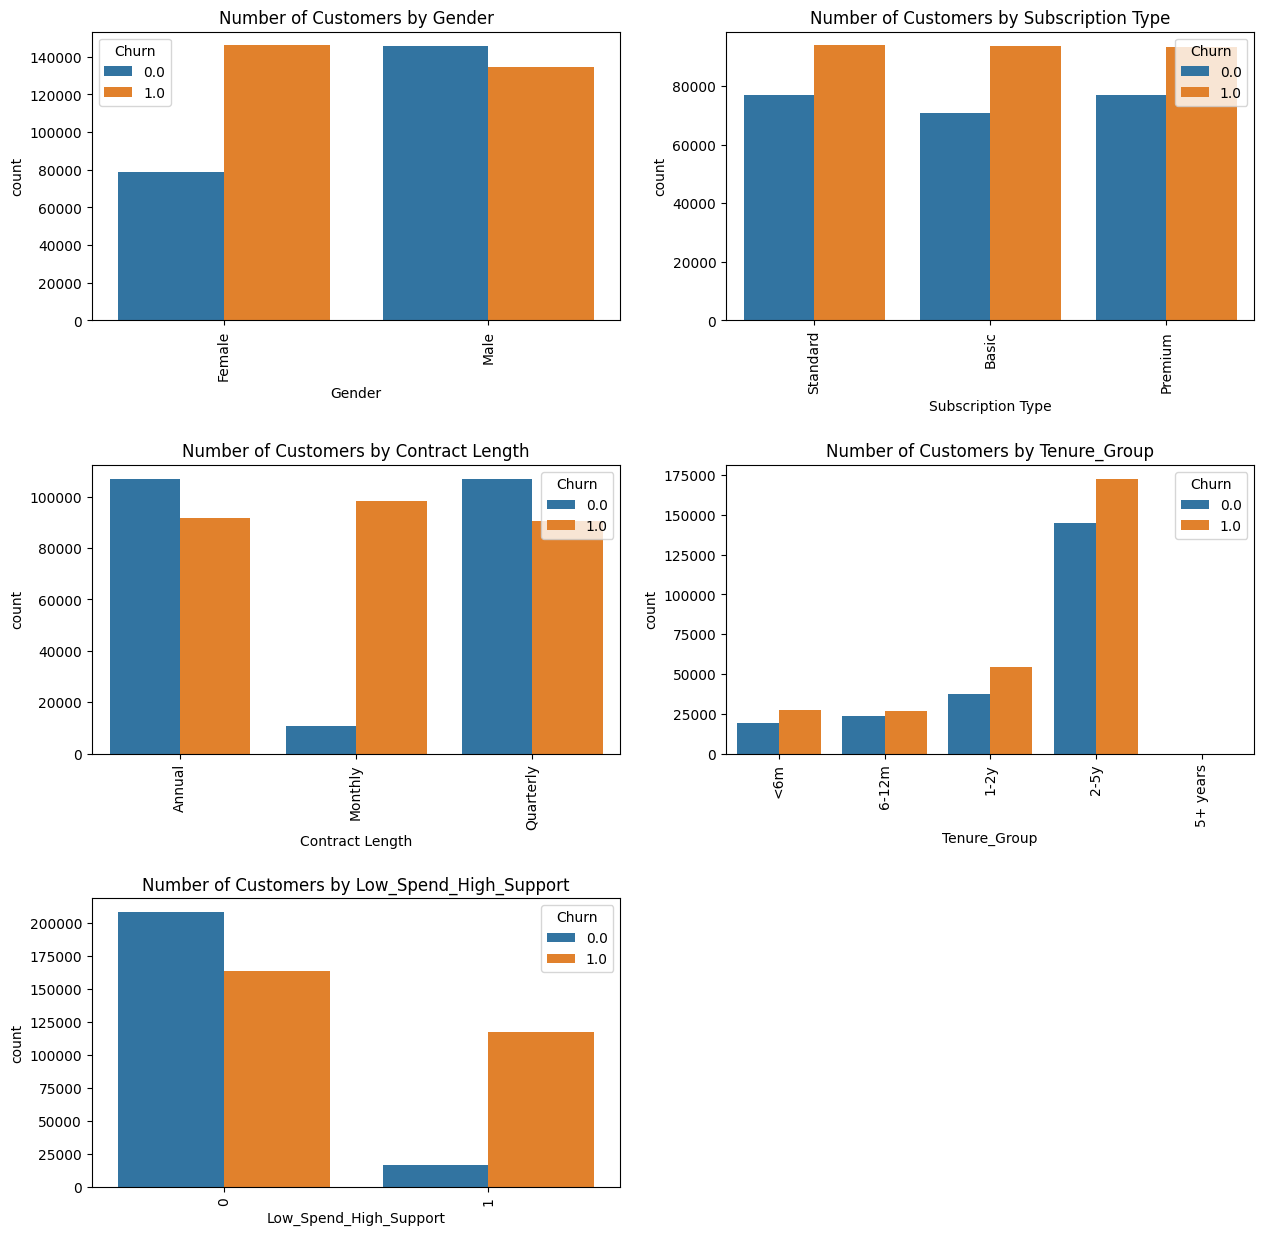

In [ ]:

features = ['Gender', 'Subscription Type', 'Contract Length', 'Tenure_Group', 'Low_Spend_High_Support']

fig = plt.figure(figsize=(15, 15))

for i, feature in enumerate(features):
    plt.subplot(3, 2, i + 1)
    plt.subplots_adjust(hspace=0.5)
    sns.countplot(x=feature, data=df, hue='Churn')
    plt.xticks(rotation=90)
    plt.title(f'Number of Customers by {feature}')


plt.show()


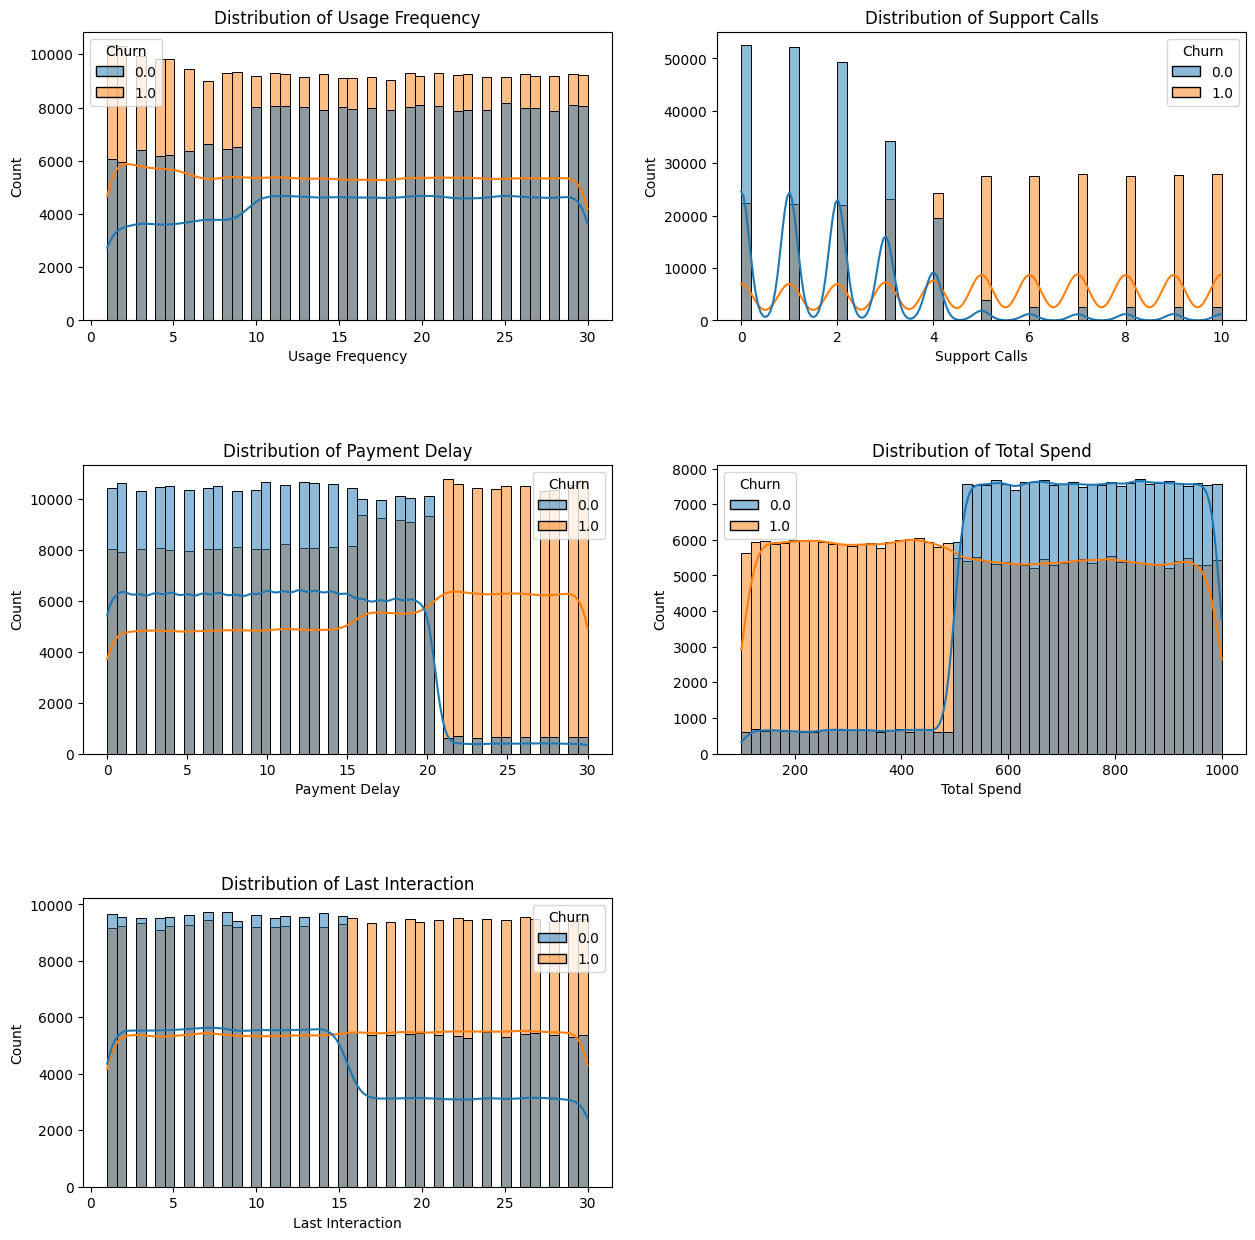

In [ ]:

numerical_features = ['Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

fig = plt.figure(figsize=(15, 15))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1)
    plt.subplots_adjust(hspace=0.5)
    sns.histplot(data=df, x=feature, hue='Churn', bins=50, kde=True)
    plt.title(f'Distribution of {feature}')


plt.show()


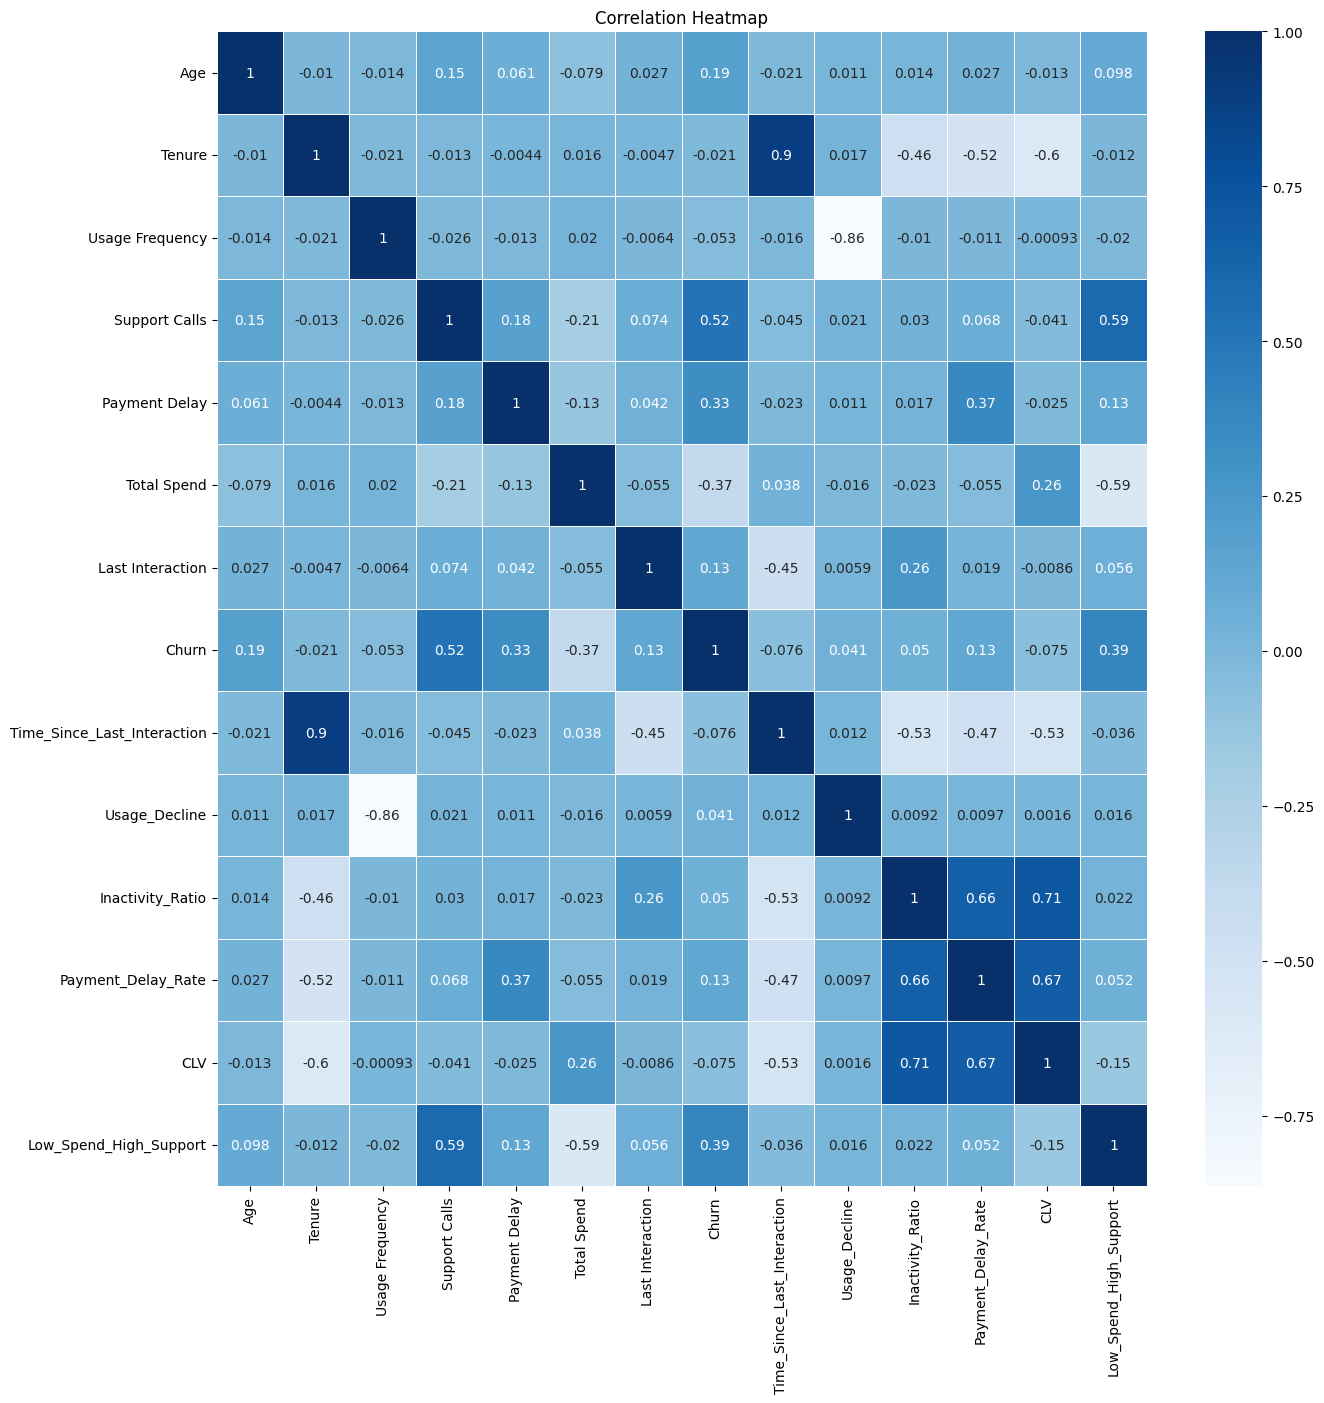

In [ ]:

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

data_corr = df[numerical_cols].corr()

plt.figure(figsize=(15, 15))
sns.heatmap(data_corr, annot=True, cmap='Blues', linewidths=0.5, linecolor='white')
plt.title('Correlation Heatmap')
plt.show()


**Highly Correlated Positively with Churn:**

Support Calls (0.52)

Low_Spend_High_Support (0.39)

Payment Delay (0.33)

Age (0.19)
Older customers are slightly more likely to churn.


**Highly Correlated Negatively with Churn:**

Total Spend (-0.37)

Customers who spend more are less likely to churn.

Time_Since_Last_Interaction (-0.11)

In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})  # convert categorical data to binary encoding


In [ ]:
df = pd.get_dummies(df, columns=['Subscription Type', 'Contract Length', 'Tenure_Group'], drop_first=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 64373
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          505206 non-null  float64
 1   Gender                       505206 non-null  int64  
 2   Tenure                       505206 non-null  float64
 3   Usage Frequency              505206 non-null  float64
 4   Support Calls                505206 non-null  float64
 5   Payment Delay                505206 non-null  float64
 6   Total Spend                  505206 non-null  float64
 7   Last Interaction             505206 non-null  float64
 8   Churn                        505206 non-null  float64
 9   Time_Since_Last_Interaction  505206 non-null  float64
 10  Usage_Decline                505206 non-null  int64  
 11  Inactivity_Ratio             505206 non-null  float64
 12  Payment_Delay_Rate           505206 non-null  float64
 13  CLV  

# **Feature importance**

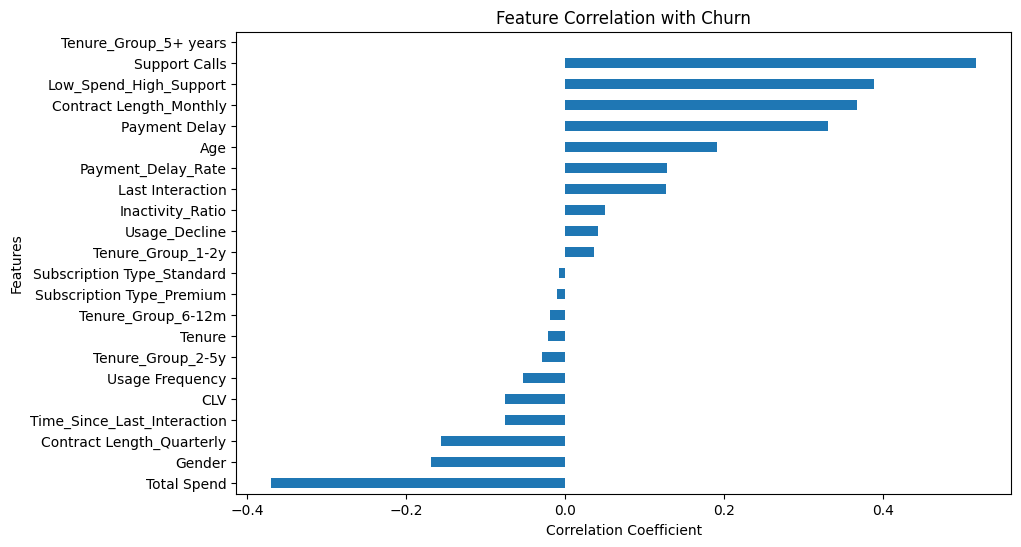

In [ ]:
correlation = df.corr()['Churn'].drop('Churn').sort_values()
correlation.plot.barh(figsize=(10, 6))
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()


# **Data Preprocessing | Data Modelling**

In [ ]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42, test_size=0.4, shuffle=True)
train_size = X_train.shape[0]
test_size = X_test.shape[0]
print('Training Data has', train_size, 'number of rows')
print('Testing Data has', test_size, 'number of rows')

Training Data has 303123 number of rows
Testing Data has 202083 number of rows


In [ ]:
y_train.value_counts()

,count
Churn,
1.0,167925
0.0,135198


In [ ]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Time_Since_Last_Interaction,...,CLV,Low_Spend_High_Support,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Tenure_Group_6-12m,Tenure_Group_1-2y,Tenure_Group_2-5y,Tenure_Group_5+ years
0,30.0,0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,22.0,...,23.300000,0,False,True,False,False,False,False,True,False
1,65.0,0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,43.0,...,11.140000,1,False,False,True,False,False,False,True,False
2,55.0,0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,11.0,...,12.333333,1,False,False,False,True,False,True,False,False
3,58.0,1,38.0,21.0,7.0,7.0,396.0,29.0,1.0,9.0,...,10.153846,1,False,True,True,False,False,False,True,False
4,23.0,1,32.0,20.0,5.0,8.0,617.0,20.0,1.0,12.0,...,18.696970,1,False,False,True,False,False,False,True,False


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", categorical_cols)


Categorical Columns: Index([], dtype='object')


In [ ]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [ ]:
print(df.columns)


Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn',
       'Time_Since_Last_Interaction', 'Usage_Decline', 'Inactivity_Ratio',
       'Payment_Delay_Rate', 'CLV', 'Low_Spend_High_Support',
       'Subscription Type_Premium', 'Subscription Type_Standard',
       'Contract Length_Monthly', 'Contract Length_Quarterly',
       'Tenure_Group_6-12m', 'Tenure_Group_1-2y', 'Tenure_Group_2-5y',
       'Tenure_Group_5+ years'],
      dtype='object')


In [ ]:
df = df.astype({col: int for col in df.select_dtypes(include=['bool']).columns})


In [ ]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Time_Since_Last_Interaction,...,CLV,Low_Spend_High_Support,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly,Tenure_Group_6-12m,Tenure_Group_1-2y,Tenure_Group_2-5y,Tenure_Group_5+ years
0,30.0,NaN,39.0,14.0,5.0,18.0,932.0,17.0,1.0,22.0,...,23.300000,0,0,1,0,0,0,0,1,0
1,65.0,NaN,49.0,1.0,10.0,8.0,557.0,6.0,1.0,43.0,...,11.140000,1,0,0,1,0,0,0,1,0
2,55.0,NaN,14.0,4.0,6.0,18.0,185.0,3.0,1.0,11.0,...,12.333333,1,0,0,0,1,0,1,0,0
3,58.0,NaN,38.0,21.0,7.0,7.0,396.0,29.0,1.0,9.0,...,10.153846,1,0,1,1,0,0,0,1,0
4,23.0,NaN,32.0,20.0,5.0,8.0,617.0,20.0,1.0,12.0,...,18.696970,1,0,0,1,0,0,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42, test_size=0.3, shuffle=True)
train_size = X_train.shape[0]
test_size = X_test.shape[0]
print('Training Data has', train_size, 'number of rows')
print('Testing Data has', test_size, 'number of rows')

Training Data has 353644 number of rows
Testing Data has 151562 number of rows


In [ ]:
y_train.value_counts()

,count
Churn,
1.0,196149
0.0,157495


In [ ]:
y_test.value_counts()

,count
Churn,
1.0,84343
0.0,67219


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
y_train_resampled.value_counts()

,count
Churn,
1.0,196149
0.0,196149


In [ ]:
X_train_resampled.shape

(392298, 22)

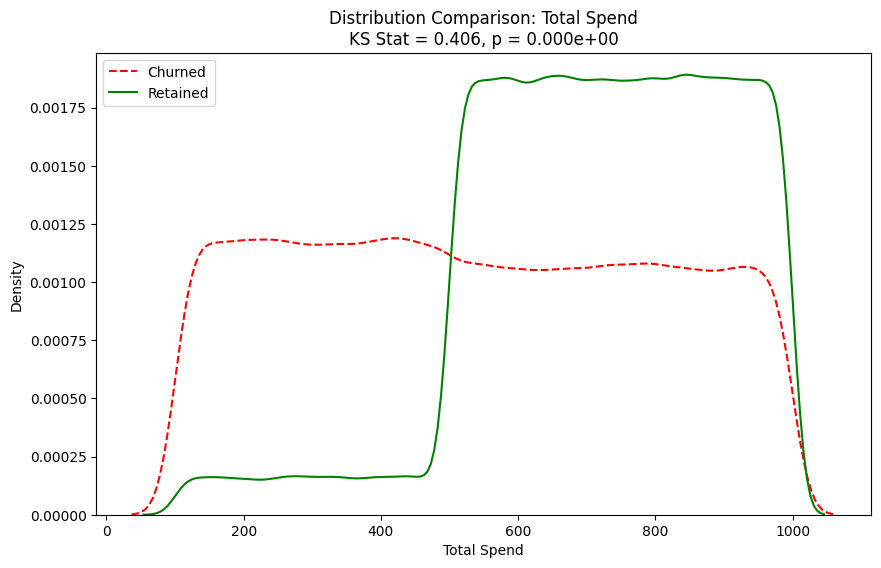


KS Test Results for Total Spend:
Statistic: 0.4057 (Maximum distance between CDFs)
P-value: 0.000e+00
Conclusion: Distributions are significantly different
Effect Size: Large


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def perform_ks_test(df, feature, target='Churn', alpha=0.05):
    """
    Performs KS test and generates comparative visualization
    Args:
        df: DataFrame containing the data
        feature: Feature column to test
        target: Binary target variable (default: 'Churn')
        alpha: Significance level (default: 0.05)
    Returns:
        Dictionary containing test results and interpretation
    """
    # Data preparation
    group1 = df[df[target] == 1][feature]  # Churned customers
    group2 = df[df[target] == 0][feature]  # Retained customers

    # KS Test execution
    ks_stat, p_value = ks_2samp(group1, group2)

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.kdeplot(group1, label='Churned', color='red', linestyle='--')
    sns.kdeplot(group2, label='Retained', color='green')
    plt.title(f'Distribution Comparison: {feature}\nKS Stat = {ks_stat:.3f}, p = {p_value:.3e}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    # Interpretation
    result = {
        'feature': feature,
        'ks_statistic': ks_stat,
        'p_value': p_value,
        'effect_size': ks_stat,  # KS statistic itself measures effect size
        'interpretation': ('Significantly different' if p_value < alpha
                          else 'Not significantly different'),
        'visualization': plt.gcf()
    }

    print(f"\nKS Test Results for {feature}:")
    print(f"Statistic: {ks_stat:.4f} (Maximum distance between CDFs)")
    print(f"P-value: {p_value:.3e}")
    print(f"Conclusion: Distributions are {result['interpretation'].lower()}")
    print(f"Effect Size: {'Large' if ks_stat > 0.3 else 'Medium' if ks_stat > 0.1 else 'Small'}")

    return result

# Example usage
results = perform_ks_test(df, 'Total Spend')

# **Autoencoder**

In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Assuming X_train_resampled is your scaled and resampled training data
input_dim = X_train_resampled.shape[1]

# Define the encoder
encoder = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu')  # Bottleneck layer
])


# Define the decoder
decoder = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(32,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')  # Output layer with sigmoid for reconstruction
])

# Combine encoder and decoder to create the autoencoder
autoencoder = keras.Sequential([encoder, decoder])

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse') # Use mean squared error for reconstruction loss

# Train the autoencoder
autoencoder.fit(X_train_resampled, X_train_resampled, epochs=50, batch_size=256, shuffle=True, validation_split=0.1)

# Get the encoded representations (latent space)
encoded_data = encoder.predict(X_train_resampled)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.6729 - val_loss: 0.5192
Epoch 2/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.5578 - val_loss: 0.5189
Epoch 3/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.5572 - val_loss: 0.5106
Epoch 4/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5510 - val_loss: 0.5105
Epoch 5/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.5494 - val_loss: 0.5103
Epoch 6/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5498 - val_loss: 0.5102
Epoch 7/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.5485 - val_loss: 0.5105
Epoch 8/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5499 - val_loss: 0.5103
Epoch 9/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.5494 - val_loss: 0.5102
Epoch 10/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.5502 - val_loss: 0.5101
Epoch 11/50
1380/1380 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.5485 - val_loss: 0.5101
Epoch 12/50
1380/1380 ━

In [ ]:
# Install necessary package
!pip install lightgbm tensorflow scikit-learn

# Import libraries
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

# Define your original training and testing data
# Make sure you have X_train, X_test, y_train, y_test already defined!

# 1. Autoencoder
input_dim = X_train.shape[1]  # Number of features

# Define the autoencoder structure
encoding_dim = input_dim // 2  # You can adjust compression here

input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)
# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Encoder model (to extract compressed features)
encoder = Model(inputs=input_layer, outputs=encoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
autoencoder.fit(X_train, X_train,
                epochs=50,
                batch_size=32,
                shuffle=True,
                validation_data=(X_test, X_test),
                verbose=1)

# Encode the data (feature extraction)
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

# 2. LightGBM Training with extracted features
lgb_model = lgb.LGBMClassifier()

param_grid_lgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'num_leaves': [31, 50, 100],
}

grid_search_lgb = GridSearchCV(estimator=lgb_model, param_grid=param_grid_lgb, cv=3, scoring='f1', n_jobs=-1)
grid_search_lgb.fit(X_train_encoded, y_train)

best_params_lgb = grid_search_lgb.best_params_
best_lgb_model = grid_search_lgb.best_estimator_

print("Best LightGBM Hyperparameters:", best_params_lgb)

# Predict and evaluate
y_pred_lgb = best_lgb_model.predict(X_test_encoded)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("\nLightGBM Performance (Tuned, After Autoencoder):")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")


Epoch 1/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - loss: 0.6562 - val_loss: 0.5137
Epoch 2/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.5093 - val_loss: 0.5051
Epoch 3/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - loss: 0.5038 - val_loss: 0.5017
Epoch 4/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.5013 - val_loss: 0.5004
Epoch 5/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 0.4999 - val_loss: 0.4982
Epoch 6/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.4991 - val_loss: 0.4973
Epoch 7/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - loss: 0.4991 - val_loss: 0.4969
Epoch 8/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 0.4987 - val_loss: 0.4966
Epoch 9/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - loss: 0.4972 - val_loss: 0.4965
Epoch 10/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 0.4972 - val_loss: 0.4963
Epoch 11/50
11052/11052 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.4955 - val_loss: 0.49

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 196149, number of negative: 157495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 353644, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.554651 -> initscore=0.219481
[LightGBM] [Info] Start training from score 0.219481
Best LightGBM Hyperparameters: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 100}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



LightGBM Performance (Tuned, After Autoencoder):
Accuracy: 0.9285
Precision: 0.8954
Recall: 0.9867
F1 Score: 0.9389


In [ ]:
# Install needed libraries
!pip install scikit-optimize
!pip install xgboost

# Import libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from xgboost import XGBClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Assume you already have your data loaded as X, y
# Example:
# X = your features
# y = your target

# Step 0: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 1: Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 2: Build and train Autoencoder on RESAMPLED data
input_dim = X_train_resampled.shape[1]

# Define Autoencoder structure
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train Autoencoder
autoencoder.fit(X_train_resampled, X_train_resampled,
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=0)

# Step 3: Transform the data
# Create an encoder model (only the compressed part)
encoder = Model(inputs=input_layer, outputs=encoded)

X_train_autoencoded = encoder.predict(X_train_resampled)
X_test_autoencoded = encoder.predict(X_test)

# Step 4: XGBoost with Bayesian Optimization
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define search space
param_space = {
    'learning_rate': Real(0.05, 0.2),
    'max_depth': Integer(3, 8),
    'n_estimators': Integer(100, 300),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'gamma': Real(0, 2),
}

opt = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Fit the model on the autoencoded resampled data
opt.fit(X_train_autoencoded, y_train_resampled)

# Step 5: Evaluate
best_params = opt.best_params_
print("Best Hyperparameters:", best_params)

best_xgb_model = opt.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_autoencoded)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("\nXGBoost Performance (Tuned) with Autoencoder:")
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")


12272/12272 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
4737/4737 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:59:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: OrderedDict([('colsample_bytree', 1.0), ('gamma', 0.0), ('learning_rate', 0.12480068356685228), ('max_depth', 8), ('n_estimators', 300), ('subsample', 0.7)])

XGBoost Performance (Tuned) with Autoencoder:
Accuracy : 0.9094
Precision: 0.8986
Recall   : 0.9434
F1 Score : 0.9204


# **t-SNE**

In [ ]:
# Install necessary library
!pip install lightgbm

# Import libraries
from sklearn.manifold import TSNE
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ======================
# Step 1: Apply t-SNE Transformation
# ======================

# Apply t-SNE on training and testing data
# Important: t-SNE is usually applied for visualization (2D or 3D), but you can still use it for feature engineering.
# Here, we reduce it to 2 components (you can change to 3 if you want)
tsne = TSNE(n_components=2, random_state=42)

# **Fit on training** and **transform training**
X_train_tsne = tsne.fit_transform(X_train_resampled)

# **Important**: t-SNE does NOT have a `.transform()` method.
# So, to transform test set, you typically refit separately (which is not ideal), or apply PCA or other embeddings.
# t-SNE is not intended for separately transforming unseen test data. **Solution**: Fit separately for test set.
X_test_tsne = tsne.fit_transform(X_test)

# ======================
# Step 2: LightGBM Classifier with GridSearchCV
# ======================

lgb_model = lgb.LGBMClassifier(random_state=42)

param_grid_lgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'num_leaves': [31, 50, 100],
}

grid_search_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

# Fit on t-SNE transformed data
grid_search_lgb.fit(X_train_tsne, y_train_resampled)

# ======================
# Step 3: Evaluate
# ======================

best_params_lgb = grid_search_lgb.best_params_
best_lgb_model = grid_search_lgb.best_estimator_

print("Best LightGBM Hyperparameters:", best_params_lgb)

# Predict on test set (t-SNE transformed)
y_pred_lgb = best_lgb_model.predict(X_test_tsne)

# Evaluate
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

# Print results
print("\nLightGBM Performance (Tuned) with t-SNE:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")


KeyboardInterrupt: 

# **Feature Agglomeration**

In [ ]:
# Install necessary library
!pip install lightgbm

# Import libraries
from sklearn.cluster import FeatureAgglomeration
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ======================
# Step 1: Apply Feature Agglomeration Transformation
# ======================

# Apply Feature Agglomeration on training and testing data
# Reduce to 2 features (like you did with t-SNE)
agglo = FeatureAgglomeration(n_clusters=16)

# Fit and transform training data
X_train_agglo = agglo.fit_transform(X_train_resampled)

# Transform test data
X_test_agglo = agglo.transform(X_test)

# ======================
# Step 2: LightGBM Classifier with GridSearchCV
# ======================

lgb_model = lgb.LGBMClassifier(random_state=42)

param_grid_lgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'num_leaves': [31, 50, 100],
}

grid_search_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

# Fit on Feature Agglomeration-transformed data
grid_search_lgb.fit(X_train_agglo, y_train_resampled)

# ======================
# Step 3: Evaluate
# ======================

best_params_lgb = grid_search_lgb.best_params_
best_lgb_model = grid_search_lgb.best_estimator_

print("Best LightGBM Hyperparameters:", best_params_lgb)

# Predict on test set (Feature Agglomeration transformed)
y_pred_lgb = best_lgb_model.predict(X_test_agglo)

# Evaluate
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

# Print results
print("\nLightGBM Performance (Tuned) with Feature Agglomeration:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 196344, number of negative: 196344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2799
[LightGBM] [Info] Number of data points in the train set: 392688, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LightGBM Hyperparameters: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 100}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



LightGBM Performance (Tuned) with Feature Agglomeration:
Accuracy: 0.9357
Precision: 0.8983
Recall: 0.9970
F1 Score: 0.9451


In [ ]:
# Install necessary libraries
!pip install scikit-optimize xgboost
!pip install scikit-optimize

# Import libraries
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.cluster import FeatureAgglomeration
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ======================
# Step 1: Apply Feature Agglomeration Transformation
# ======================

# Apply Feature Agglomeration
agglo = FeatureAgglomeration(n_clusters=16)

# Fit and transform training data
X_train_agglo = agglo.fit_transform(X_train_resampled)

# Transform test data
X_test_agglo = agglo.transform(X_test)

# ======================
# Step 2: XGBoost Classifier with Bayesian Optimization
# ======================

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')  # Avoid warning messages

# Define the hyperparameter search space
param_space = {
    'learning_rate': Real(0.05, 0.2),
    'max_depth': Integer(3, 8),
    'n_estimators': Integer(100, 300),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'gamma': Real(0, 2),
}

# Set up Bayesian Optimization
opt = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=20,  # 20 iterations for tuning
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Fit on Feature Agglomeration-transformed training data
opt.fit(X_train_agglo, y_train_resampled)

# Best hyperparameters
best_params = opt.best_params_
print("Best Hyperparameters:", best_params)

# ======================
# Step 3: Evaluate
# ======================

# Best model
best_xgb_model = opt.best_estimator_

# Predict on test set (Feature Agglomeration-transformed)
y_pred_xgb = best_xgb_model.predict(X_test_agglo)

# Evaluate
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Print results
print("\nXGBoost Performance (Tuned) with Feature Agglomeration:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:26:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: OrderedDict([('colsample_bytree', 0.9264029792764612), ('gamma', 0.0), ('learning_rate', 0.1390898326959507), ('max_depth', 8), ('n_estimators', 290), ('subsample', 1.0)])

XGBoost Performance (Tuned) with Feature Agglomeration:
Accuracy: 0.9334
Precision: 0.8987
Recall: 0.9920
F1 Score: 0.9430


# **PCA**

In [ ]:

from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)  #number of components
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test)

In [ ]:

from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)  #number of components
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test)



!pip install lightgbm
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lgb_model = lgb.LGBMClassifier()
param_grid_lgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'num_leaves': [31, 50, 100],
}

grid_search_lgb = GridSearchCV(estimator=lgb_model, param_grid=param_grid_lgb, cv=3, scoring='f1', n_jobs=-1)
grid_search_lgb.fit(X_train_pca, y_train_resampled) # Use PCA transformed data

best_params_lgb = grid_search_lgb.best_params_
best_lgb_model = grid_search_lgb.best_estimator_
print("Best LightGBM Hyperparameters:", best_params_lgb)

y_pred_lgb = best_lgb_model.predict(X_test_pca) # Use PCA transformed data
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("LightGBM Performance (Tuned) with PCA:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 196149, number of negative: 196149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 392298, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best LightGBM Hyperparameters: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 100}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM Performance (Tuned) with PCA:
Accuracy: 0.9134
Precision: 0.8954
Recall: 0.9560
F1 Score: 0.9247


In [ ]:
!pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [ ]:

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier



model = XGBClassifier()
# Define the hyperparameter search space
param_space = {
    'learning_rate': Real(0.05, 0.2),
    'max_depth': Integer(3, 8),
    'n_estimators': Integer(100, 300),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'gamma': Real(0, 2),
}
# Set up Bayesian Optimization
opt = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=20,  # Fewer iterations 20 is good
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
opt.fit(X_train_pca, y_train_resampled) # Use PCA transformed data here
best_params = opt.best_params_
print("Best Hyperparameters:", best_params)

best_xgb_model = opt.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_pca)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Performance (Tuned) with PCA:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters: OrderedDict([('colsample_bytree', 0.9512165066659852), ('gamma', 1.7666305547617245), ('learning_rate', 0.09551151648262626), ('max_depth', 8), ('n_estimators', 273), ('subsample', 0.7186938822532214)])
XGBoost Performance (Tuned) with PCA:
Accuracy: 0.9137
Precision: 0.8962
Recall: 0.9557
F1 Score: 0.9250


In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming X_train_pca, y_train_resampled, X_test_pca, and y_test are defined from your previous code

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

dt_classifier = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_pca, y_train_resampled) # Use PCA transformed data here

best_params = grid_search.best_params_
best_dt_model = grid_search.best_estimator_
print("Best Hyperparameters:", best_params)

y_pred_proba = best_dt_model.predict_proba(X_test_pca)[:, 1] # Use PCA transformed data here
y_pred = (y_pred_proba > 0.5).astype(int)
y_test = y_test.astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Performance (Tuned) with PCA:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree Performance (Tuned) with PCA:
Accuracy: 0.8883
Precision: 0.8914
Recall: 0.9102
F1 Score: 0.9007


# **MODELING**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
!pip install optuna
import optuna
from optuna.samplers import TPESampler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 14.5 MB/s eta 0:00:00


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "Neural Network": MLPClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "Neural Network": MLPClassifier()
}



Processing: Logistic Regression...
	Model: Logistic Regression
	Accuracy: 0.8475541362610681
	Precision: 0.8722312723382528
	Recall: 0.8506692908717973
	F1 Score: 0.8613153582511509
	Training Time (s): 4.151031494140625
	Prediction Time (s): 0.03405165672302246


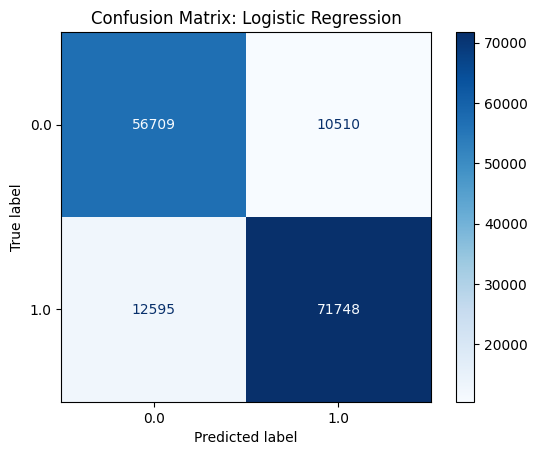

Processing: Decision Tree...
	Model: Decision Tree
	Accuracy: 0.8826750768662329
	Precision: 0.9019529693104823
	Recall: 0.8854202482719372
	F1 Score: 0.8936101471820032
	Training Time (s): 14.30236005783081
	Prediction Time (s): 0.05324387550354004


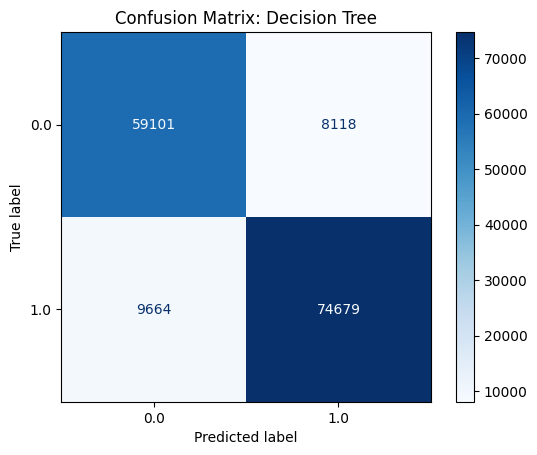

Processing: kNN...
	Model: kNN
	Accuracy: 0.8929481004473416
	Precision: 0.8976253852619781
	Recall: 0.9115990657197396
	F1 Score: 0.9045582621074242
	Training Time (s): 0.03689074516296387
	Prediction Time (s): 424.5602376461029


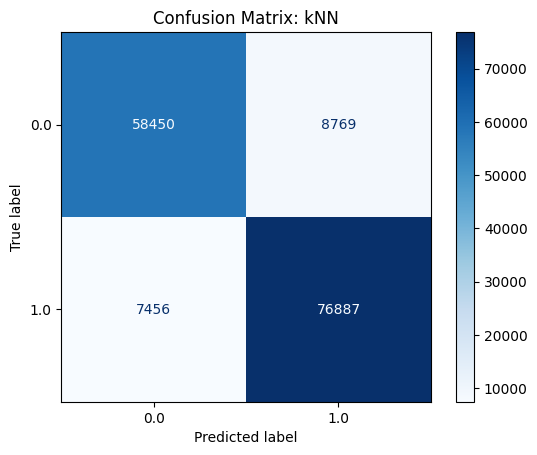

Processing: Random Forest...
	Model: Random Forest
	Accuracy: 0.9331626661036407
	Precision: 0.8961956927939182
	Recall: 0.9951626098194278
	F1 Score: 0.9430898876404494
	Training Time (s): 111.07777547836304
	Prediction Time (s): 4.962414503097534


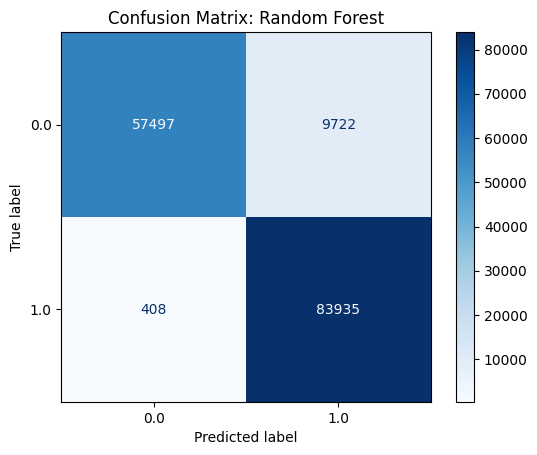

Processing: Gradient Boosting...
	Model: Gradient Boosting
	Accuracy: 0.9191815890526649
	Precision: 0.896042541035839
	Recall: 0.9669563567812385
	F1 Score: 0.930149805258866
	Training Time (s): 163.84758758544922
	Prediction Time (s): 0.38904786109924316


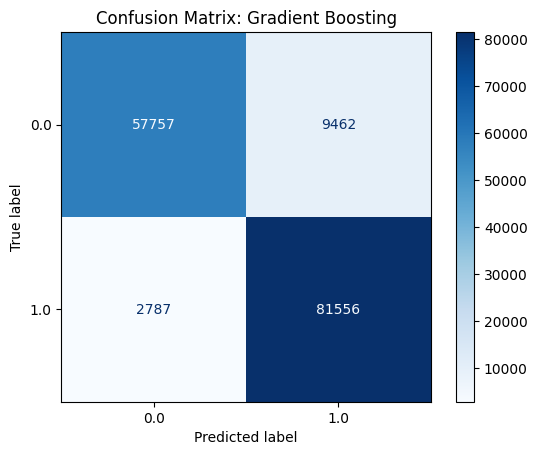

Processing: XGBoost...
	Model: XGBoost
	Accuracy: 0.9328921497472982
	Precision: 0.8964551441033096
	Recall: 0.9942496709863297
	F1 Score: 0.9428232529639603
	Training Time (s): 6.267834901809692
	Prediction Time (s): 0.5380983352661133


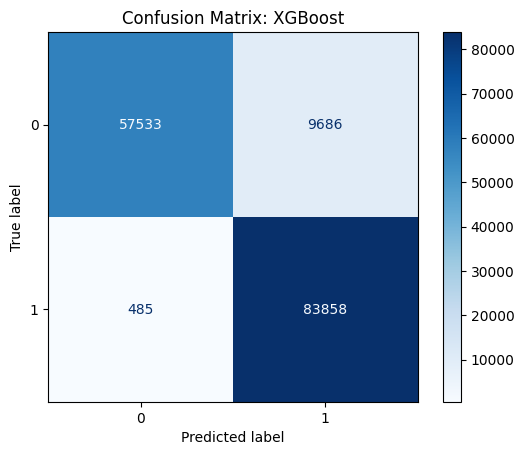

Processing: Neural Network...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


	Model: Neural Network
	Accuracy: 0.922665311885565
	Precision: 0.8970498184840134
	Recall: 0.9726592604009817
	F1 Score: 0.9333257487414318
	Training Time (s): 336.1696472167969
	Prediction Time (s): 0.2261366844177246


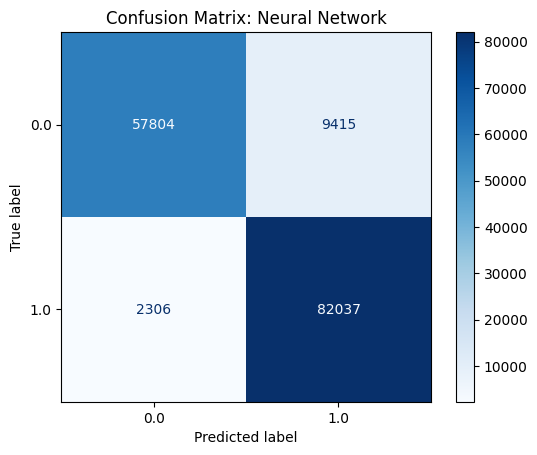

In [ ]:
import time
# Initialize lists to store ROC data
roc_data = {}

# Train, evaluate, and collect ROC curve data
timed_results = []

for model_name, model in models.items():
    print(f'Processing: {model_name}...')

    # Measure training time
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time

    # Measure prediction time
    start_time = time.time()
    y_pred = model.predict(X_test_scaled)
    predict_time = time.time() - start_time

    # Get probabilities for ROC curve if available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_scaled)
    else:
        y_prob = None

    # Evaluate metrics
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Training Time (s)": train_time,
        "Prediction Time (s)": predict_time
    }
    for key, value in metrics.items():
        print(f'\t{key}: {value}')
    timed_results.append(metrics)
    print('==============================')

    # Collect ROC curve data
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        roc_data[model_name] = (fpr, tpr, roc_auc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_ if hasattr(model, "classes_") else [0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# Convert results to DataFrame
timed_results_df = pd.DataFrame(timed_results)

In [ ]:
timed_results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.847554,0.872231,0.850669,0.861315,4.151031,0.034052
1,Decision Tree,0.882675,0.901953,0.885420,0.893610,14.302360,0.053244
2,kNN,0.892948,0.897625,0.911599,0.904558,0.036891,424.560238
3,Random Forest,0.933163,0.896196,0.995163,0.943090,111.077775,4.962415
4,Gradient Boosting,0.919182,0.896043,0.966956,0.930150,163.847588,0.389048
5,XGBoost,0.932892,0.896455,0.994250,0.942823,6.267835,0.538098
6,Neural Network,0.922665,0.897050,0.972659,0.933326,336.169647,0.226137


In [ ]:

timed_results_df_sorted = timed_results_df.sort_values(by='Accuracy', ascending=False) # Replace 'Accuracy' with the desired column name

timed_results_df_sorted


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
3,Random Forest,0.933163,0.896196,0.995163,0.943090,111.077775,4.962415
5,XGBoost,0.932892,0.896455,0.994250,0.942823,6.267835,0.538098
6,Neural Network,0.922665,0.897050,0.972659,0.933326,336.169647,0.226137
4,Gradient Boosting,0.919182,0.896043,0.966956,0.930150,163.847588,0.389048
2,kNN,0.892948,0.897625,0.911599,0.904558,0.036891,424.560238
1,Decision Tree,0.882675,0.901953,0.885420,0.893610,14.302360,0.053244
0,Logistic Regression,0.847554,0.872231,0.850669,0.861315,4.151031,0.034052


# **XGBooster with Hyperparameter optimization**

▶ XGBOOST OPTIMIZATION


In [ ]:
!pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.8 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
model = XGBClassifier()

# Define the hyperparameter search space
param_space = {
    'learning_rate': Real(0.05, 0.2),
    'max_depth': Integer(3, 8),
    'n_estimators': Integer(100, 300),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'gamma': Real(0, 2),
}

# Set up Bayesian Optimization
opt = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=20,  # Fewer iterations 20 is good
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt.fit(X_train, y_train)


best_params = opt.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: OrderedDict([('colsample_bytree', 1.0), ('gamma', 1.7377723752337055), ('learning_rate', 0.2), ('max_depth', 8), ('n_estimators', 300), ('subsample', 1.0)])


In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

# Best hyperparameters from Bayesian Optimization
best_params = {
    'colsample_bytree': 1.0,
    'gamma':  1.7377723752337055,
    'learning_rate': 0.2,
    'max_depth': 8,
    'n_estimators': 300,
    'subsample': 1.0,
}

optimized_model = XGBClassifier(**best_params)

# Train the model and measure training time
start_time = time.time()
optimized_model.fit(X_train, y_train)
training_time = time.time() - start_time

# Make predictions and measure prediction time
start_time = time.time()
y_pred = optimized_model.predict(X_test)
prediction_time = time.time() - start_time


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Optimized Model Performance:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1 Score: {f1:.6f}")
print(f"Training Time (s): {training_time:.6f}")
print(f"Prediction Time (s): {prediction_time:.6f}")

Optimized Model Performance:
Accuracy: 0.934185
Precision: 0.896291
Recall: 0.997107
F1 Score: 0.944015
Training Time (s): 17.361438
Prediction Time (s): 0.333119


In [ ]:
# This is Training and Testing

optimized_model.fit(X_train, y_train)
y_train_pred = optimized_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("Training Results:")
print(f"Accuracy: {train_accuracy:.6f}")
print(f"Precision: {train_precision:.6f}")
print(f"Recall: {train_recall:.6f}")
print(f"F1 Score: {train_f1:.6f}")



y_test_pred = optimized_model.predict(X_test)


test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Print testing results
print("\nTesting Results:")
print(f"Accuracy: {test_accuracy:.6f}")
print(f"Precision: {test_precision:.6f}")
print(f"Recall: {test_recall:.6f}")
print(f"F1 Score: {test_f1:.6f}")


Training Results:
Accuracy: 0.936758
Precision: 0.900158
Recall: 0.996508
F1 Score: 0.945886

Testing Results:
Accuracy: 0.933222
Precision: 0.896366
Recall: 0.995044
F1 Score: 0.943131


In [ ]:
#Testing the cv Agine with 5 the old one is with 3

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(optimized_model, X_train, y_train, cv=5, scoring='f1') # Example using 5-fold cross-validation and F1 score
print("Cross-Validation F1 Scores:", cv_scores)
print("Average F1 Score:", cv_scores.mean())
print("Standard Deviation of F1 Scores:", cv_scores.std())


Cross-Validation F1 Scores: [0.94408253 0.94414057 0.94356916 0.94367015 0.94455812]
Average F1 Score: 0.9440041064563415
Standard Deviation of F1 Scores: 0.00035564442673326115


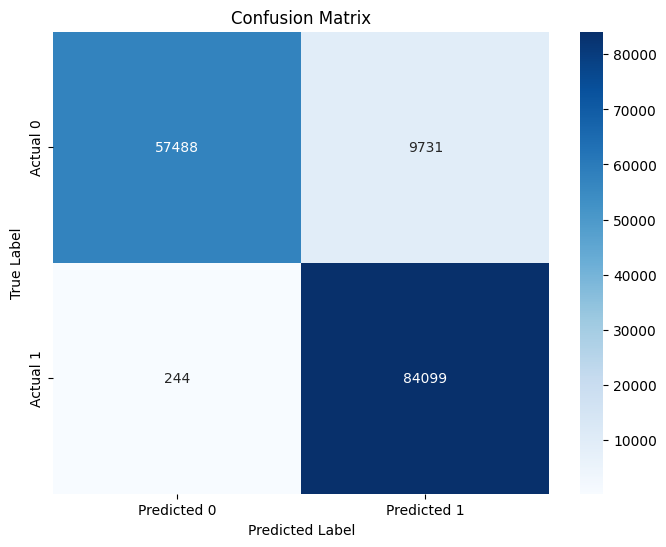

AUC Score: 0.9525


In [ ]:


from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

y_pred_proba = optimized_model.predict_proba(X_test)[:, 1] # Probability of positive class
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc:.4f}")


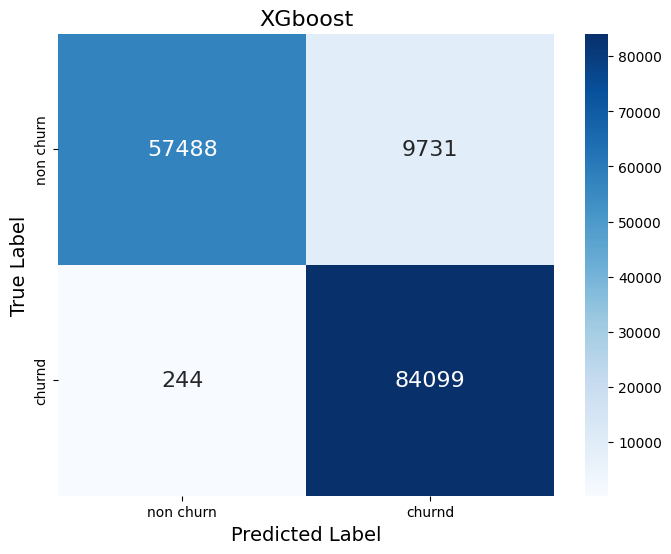

In [ ]:
# just more clear
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 16},
            xticklabels=['non churn', 'churnd'],
            yticklabels=['non churn', 'churnd'])
plt.title('XGboost', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.show()


▶XGBOOST NO TUNING

In [ ]:

untuned_model = XGBClassifier()


start_time = time.time()
untuned_model.fit(X_train, y_train)
training_time = time.time() - start_time

start_time = time.time()
y_pred = untuned_model.predict(X_test)
prediction_time = time.time() - start_time

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Untuned Model Performance:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1 Score: {f1:.6f}")
print(f"Training Time (s): {training_time:.6f}")
print(f"Prediction Time (s): {prediction_time:.6f}")


Untuned Model Performance:
Accuracy: 0.932892
Precision: 0.896455
Recall: 0.994250
F1 Score: 0.942823
Training Time (s): 4.032909
Prediction Time (s): 0.316478


# **XGB TUNNING**

In [ ]:
param_space = {
    'learning_rate': Real(0.01, 0.3),
    'max_depth': Integer(3, 10),
    'n_estimators': Integer(100, 500),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5),
    'min_child_weight': Integer(1, 10),
    'reg_alpha': Real(0, 1),
    'reg_lambda': Real(0, 1)
}


In [ ]:

from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

# Define the model
model = XGBClassifier()

# Define the hyperparameter search space (smaller range)
param_space = {
    'learning_rate': Real(0.01, 0.3),
    'max_depth': Integer(3, 10),
    'n_estimators': Integer(100, 500),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5),
    'min_child_weight': Integer(1, 10),
    'reg_alpha': Real(0, 1),
    'reg_lambda': Real(0, 1)
}


# Set up Bayesian Optimization
opt = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=20,  # Fewer iterations
    cv=3,      # Fewer cross-validation folds
    scoring='f1',
    n_jobs=-1,  # Use all CPU cores
    random_state=42
)

# Perform hyperparameter optimization
opt.fit(X_train, y_train)

# Get the best hyperparameters
best_params = opt.best_params_
print("Best Hyperparameters:", best_params)


Best Hyperparameters: OrderedDict([('colsample_bytree', 0.9349553422213137), ('gamma', 4.416576386904311), ('learning_rate', 0.09798893186641074), ('max_depth', 10), ('min_child_weight', 9), ('n_estimators', 125), ('reg_alpha', 0.13830853827857517), ('reg_lambda', 0.3535873976284181), ('subsample', 0.8542916407516681)])


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# Predict using the best model
start_time = time.time()
y_pred = opt.predict(X_test)
pred_time = time.time() - start_time

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Optimized Model Performance:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1 Score: {f1:.6f}")
print(f"Prediction Time (s): {pred_time:.6f}")


Optimized Model Performance:
Accuracy: 0.934199
Precision: 0.896234
Recall: 0.997214
F1 Score: 0.944031
Prediction Time (s): 0.685184


In [ ]:
#  Hyperparameter tuning with Optuna for XGBoost
!pip install optuna
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1)
    }

    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', **params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(objective, n_trials=30)

print("Best hyperparameters:", study.best_params)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 12.9 MB/s eta 0:00:00


[I 2025-04-11 21:36:04,534] A new study created in memory with name: no-name-9b5dcc86-f78e-47ad-be80-3019b26698e1
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:36:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[I 2025-04-11 21:36:42,860] Trial 0 finished with value: 0.9444497422463553 and parameters: {'n_estimators': 268, 'max_depth': 11, 'learning_rate': 0.05006757694039588, 'subsample': 0.8302631524015109, 'colsample_bytree': 0.9605638932726098, 'gamma': 0.7533567762906473, 'reg_alpha': 0.2967693184393937, 'reg_lambda': 0.8460120363018997}. Best is trial 0 with value: 0.9444497422463553.
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:36:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[I 2025-04-11 21:37:00,611] Trial 1 finished with value: 0.9435127879679654

Best hyperparameters: {'n_estimators': 159, 'max_depth': 14, 'learning_rate': 0.0835486596111634, 'subsample': 0.9031381646495353, 'colsample_bytree': 0.8944569971107239, 'gamma': 2.327833675591159, 'reg_alpha': 0.7677611525976891, 'reg_lambda': 0.5761190102008025}


In [ ]:

# Initialize the best XGBoost model with optimized hyperparameters from Optuna
best_xgb_params = study.best_params
best_xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', **best_xgb_params)

# Train the model
best_xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = best_xgb_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("\nXGBoost Model Performance (Optuna):")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")

print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:49:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Model Performance (Optuna):
Accuracy: 0.9349
Precision: 0.8963
Recall: 0.9985
F1 Score: 0.9446
              precision    recall  f1-score   support

         0.0       1.00      0.85      0.92     67219
         1.0       0.90      1.00      0.94     84343

    accuracy                           0.93    151562
   macro avg       0.95      0.93      0.93    151562
weighted avg       0.94      0.93      0.93    151562



# **Decision Tree with Hyperparameter optimization**

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV

y_pred_proba = grid_search.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)


y_test = y_test.astype(int)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}


dt_classifier = DecisionTreeClassifier(random_state=42)

# GridSearchCV for hyperparameter optimization
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
best_dt_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)

y_pred = best_dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Performance (Tuned):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}


dt_classifier = DecisionTreeClassifier(random_state=42)


grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
best_dt_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)


y_pred_proba = best_dt_model.predict_proba(X_test)[:, 1]

y_pred = (y_pred_proba > 0.5).astype(int)

y_test = y_test.astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Performance (Tuned):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree Performance (Tuned):
Accuracy: 0.9325
Precision: 0.8964
Recall: 0.9936
F1 Score: 0.9425


Decision Tree Performance (Tuned):
Training Time (s): 3.702606
Prediction Time (s): 0.017926


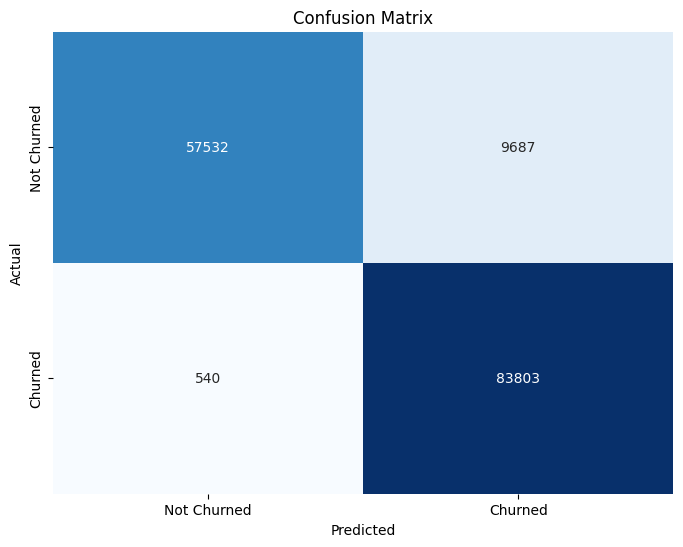

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time



start_time = time.time()

best_dt_model.fit(X_train, y_train)
training_time = time.time() - start_time

start_time = time.time()
y_pred = best_dt_model.predict(X_test)
prediction_time = time.time() - start_time

print("Decision Tree Performance (Tuned):")
print(f"Training Time (s): {training_time:.6f}")
print(f"Prediction Time (s): {prediction_time:.6f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Decision Tree Performance (Tuned):
Training Time (s): 8.508973
Prediction Time (s): 0.020337
AUC: 0.9518


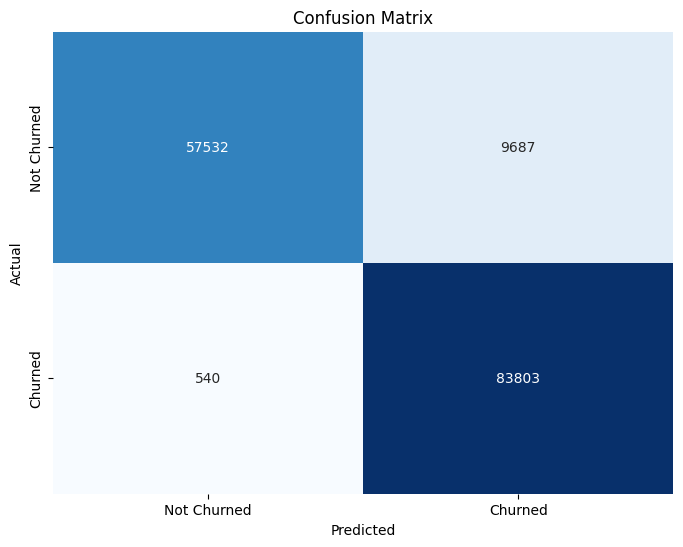

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

start_time = time.time()

best_dt_model.fit(X_train, y_train)
training_time = time.time() - start_time

start_time = time.time()
y_pred_proba = best_dt_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)
prediction_time = time.time() - start_time

auc = roc_auc_score(y_test, y_pred_proba)

print("Decision Tree Performance (Tuned):")
print(f"Training Time (s): {training_time:.6f}")
print(f"Prediction Time (s): {prediction_time:.6f}")
print(f"AUC: {auc:.4f}")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# **Untuned LightGBM Model Performance**

In [ ]:


!pip install lightgbm
import time
import lightgbm as lgb

untuned_lgb_model = lgb.LGBMClassifier()

start_time = time.time()
untuned_lgb_model.fit(X_train, y_train)
training_time = time.time() - start_time

start_time = time.time()
y_pred = untuned_lgb_model.predict(X_test)
prediction_time = time.time() - start_time


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("Untuned LightGBM Model Performance:")
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1 Score: {f1:.6f}")
print(f"Training Time (s): {training_time:.6f}")
print(f"Prediction Time (s): {prediction_time:.6f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 196149, number of negative: 157495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1356
[LightGBM] [Info] Number of data points in the train set: 353644, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.554651 -> initscore=0.219481
[LightGBM] [Info] Start training from score 0.219481


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Untuned LightGBM Model Performance:
Accuracy: 0.934918
Precision: 0.896329
Recall: 0.998542
F1 Score: 0.944679
Training Time (s): 5.504045
Prediction Time (s): 0.806858


In [ ]:

y_pred_proba = untuned_lgb_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


AUC: 0.9529


# **LightGBM with Optimization**

**LightGBM with Optimization**

In [ ]:


!pip install lightgbm

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


lgb_model = lgb.LGBMClassifier()

param_grid_lgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'num_leaves': [31, 50, 100],
}

grid_search_lgb = GridSearchCV(estimator=lgb_model, param_grid=param_grid_lgb, cv=3, scoring='f1', n_jobs=-1)
grid_search_lgb.fit(X_train, y_train)

best_params_lgb = grid_search_lgb.best_params_
best_lgb_model = grid_search_lgb.best_estimator_

print("Best LightGBM Hyperparameters:", best_params_lgb)

y_pred_lgb = best_lgb_model.predict(X_test)
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("LightGBM Performance (Tuned):")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 196149, number of negative: 157495
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1356
[LightGBM] [Info] Number of data points in the train set: 353644, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.554651 -> initscore=0.219481
[LightGBM] [Info] Start training from score 0.219481
Best LightGBM Hyperparameters: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 100}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM Performance (Tuned):
Accuracy: 0.9351
Precision: 0.8963
Recall: 0.9991
F1 Score: 0.9449


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM Performance (Tuned):
Accuracy: 0.9351
Precision: 0.8963
Recall: 0.9991
F1 Score: 0.9449
Prediction Time: 0.8701 seconds
Training Time (s): 0.8702


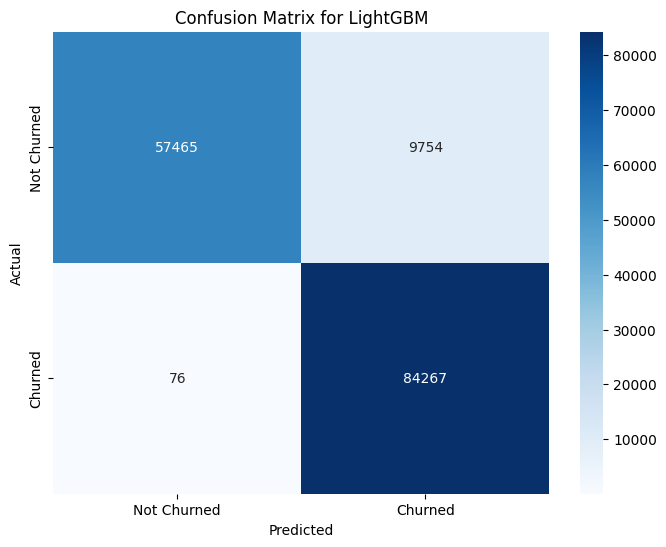

In [ ]:

import time
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



start_time = time.time()
y_pred_lgb = best_lgb_model.predict(X_test)
end_time = time.time()
prediction_time = end_time-start_time
training_time = time.time() - start_time

accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("LightGBM Performance (Tuned):")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")
print(f"Prediction Time: {prediction_time:.4f} seconds")
print(f"Training Time (s): {training_time:.4f}")

cm = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix for LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM Performance (Tuned):
Accuracy: 0.9351
Precision: 0.8963
Recall: 0.9991
F1 Score: 0.9449
AUC Score: 0.9532
Prediction Time: 0.8713 seconds
Training Time (s): 0.8714


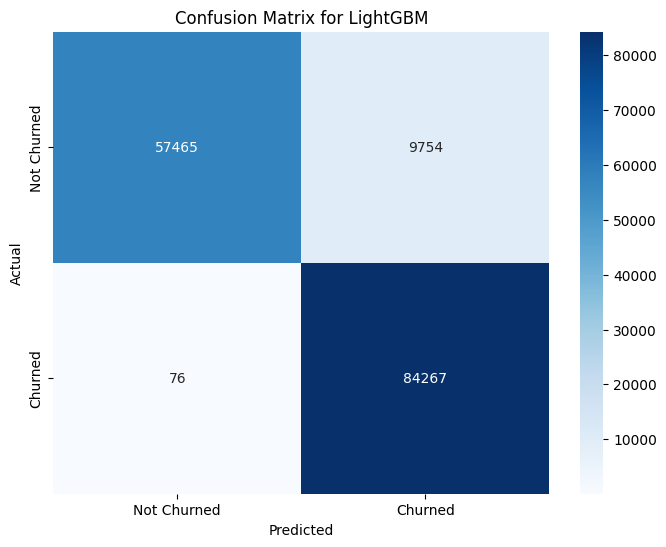

In [ ]:

import matplotlib.pyplot as plt

start_time = time.time()
y_pred_proba_lgb = best_lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_pred_proba_lgb > 0.5).astype(int)
end_time = time.time()
prediction_time = end_time - start_time

training_time = time.time() - start_time

accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)


print("LightGBM Performance (Tuned):")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")
print(f"AUC Score: {auc_lgb:.4f}")
print(f"Prediction Time: {prediction_time:.4f} seconds")
print(f"Training Time (s): {training_time:.4f}")

cm = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix for LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
!pip install lightgbm

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def tune_and_evaluate_lightgbm(X_train, y_train, X_test, y_test,
                                param_grid=None, cv_folds=3, scoring_metric='f1'):
    """
    Tunes and evaluates a LightGBM model using GridSearchCV.

    Parameters:
        X_train (DataFrame): Training features
        y_train (Series): Training labels
        X_test (DataFrame): Testing features
        y_test (Series): Testing labels
        param_grid (dict): Parameter grid for tuning
        cv_folds (int): Number of cross-validation folds
        scoring_metric (str): Scoring metric for evaluation

    Returns:
        dict: Contains best parameters and evaluation metrics
    """

    # Default hyperparameter grid
    if param_grid is None:
        param_grid = {
            'learning_rate': [0.01, 0.1, 0.2],
            'n_estimators': [50, 100, 200],
            'num_leaves': [31, 50, 100],
        }

    # Initialize LightGBM Classifier
    lgb_model = lgb.LGBMClassifier()

    # Grid search
    grid_search = GridSearchCV(estimator=lgb_model,
                               param_grid=param_grid,
                               cv=cv_folds,
                               scoring=scoring_metric,
                               n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # Predictions
    y_pred = best_model.predict(X_test)

    # Evaluation
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    }

    # Display results
    print("\n✅ Best LightGBM Hyperparameters:")
    print(best_params)
    print("\n📊 Performance on Test Set:")
    for key, value in metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")

    return {
        "best_params": best_params,
        "metrics": metrics,
        "model": best_model
    }


# **Extra tree**

Extra tree untuned

In [ ]:


from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    log_loss,
    balanced_accuracy_score,
    matthews_corrcoef,
    average_precision_score
)

extra_trees_model = ExtraTreesClassifier(random_state=42)

extra_trees_model.fit(X_train, y_train)

y_pred_et = extra_trees_model.predict(X_test)


accuracy_et = accuracy_score(y_test, y_pred_et)
precision_et = precision_score(y_test, y_pred_et)
recall_et = recall_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et)

print("\nExtraTreesClassifier Model Performance (Untuned):")
print(f"Accuracy: {accuracy_et:.4f}")
print(f"Precision: {precision_et:.4f}")
print(f"Recall: {recall_et:.4f}")
print(f"F1 Score: {f1_et:.4f}")

print(classification_report(y_test, y_pred_et))



ExtraTreesClassifier Model Performance (Untuned):
Accuracy: 0.9217
Precision: 0.8962
Recall: 0.9718
F1 Score: 0.9325
              precision    recall  f1-score   support

         0.0       0.96      0.86      0.91     67219
         1.0       0.90      0.97      0.93     84343

    accuracy                           0.92    151562
   macro avg       0.93      0.92      0.92    151562
weighted avg       0.92      0.92      0.92    151562



In [ ]:

import time
from sklearn.metrics import confusion_matrix, roc_auc_score



start_time_train = time.time()
extra_trees_model.fit(X_train, y_train)
end_time_train = time.time()
training_time = end_time_train - start_time_train


start_time_pred = time.time()
y_pred_et = extra_trees_model.predict(X_test)
end_time_pred = time.time()
prediction_time = end_time_pred - start_time_pred


y_prob = extra_trees_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)


cm = confusion_matrix(y_test, y_pred_et)


print("\nExtraTreesClassifier Model Performance:")
print(f"Training Time: {training_time:.4f} seconds")
print(f"Prediction Time: {prediction_time:.4f} seconds")
print(f"Accuracy: {accuracy_et:.4f}")
print(f"Precision: {precision_et:.4f}")
print(f"Recall: {recall_et:.4f}")
print(f"F1 Score: {f1_et:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, y_pred_et))



ExtraTreesClassifier Model Performance:
Training Time: 59.2412 seconds
Prediction Time: 5.8993 seconds
Accuracy: 0.9217
Precision: 0.8962
Recall: 0.9718
F1 Score: 0.9325
ROC AUC: 0.9495
Confusion Matrix:
 [[57726  9493]
 [ 2381 81962]]
              precision    recall  f1-score   support

         0.0       0.96      0.86      0.91     67219
         1.0       0.90      0.97      0.93     84343

    accuracy                           0.92    151562
   macro avg       0.93      0.92      0.92    151562
weighted avg       0.92      0.92      0.92    151562



* EXTRA TREE TUNNED



In [ ]:

!pip install optuna
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    model = ExtraTreesClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_params)

best_et_params = study.best_params
best_et_model = ExtraTreesClassifier(random_state=42, **best_et_params)
best_et_model.fit(X_train, y_train)
y_pred_et = best_et_model.predict(X_test)

accuracy_et = accuracy_score(y_test, y_pred_et)
precision_et = precision_score(y_test, y_pred_et)
recall_et = recall_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et)

print("\nExtraTreesClassifier Model Performance (Tuned):")
print(f"Accuracy: {accuracy_et:.4f}")
print(f"Precision: {precision_et:.4f}")
print(f"Recall: {recall_et:.4f}")
print(f"F1 Score: {f1_et:.4f}")


[I 2025-04-12 14:22:13,303] A new study created in memory with name: no-name-76220b2a-823e-4607-bef5-7e9560a1cba0
[I 2025-04-12 14:24:44,132] Trial 0 finished with value: 0.9295900025678336 and parameters: {'n_estimators': 167, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9295900025678336.
[I 2025-04-12 14:26:38,598] Trial 1 finished with value: 0.929929838571673 and parameters: {'n_estimators': 174, 'max_depth': 37, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.929929838571673.
[I 2025-04-12 14:27:56,890] Trial 2 finished with value: 0.9296441695387214 and parameters: {'n_estimators': 120, 'max_depth': 33, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.929929838571673.
[I 2025-04-12 14:29:38,385] Trial 3 finished with value: 0.9233900175916664 and parameters: {'n_estimators': 176, 'max_depth': 17, 'min_

Best hyperparameters: {'n_estimators': 105, 'max_depth': 31, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}

ExtraTreesClassifier Model Performance (Tuned):
Accuracy: 0.9210
Precision: 0.8962
Recall: 0.9704
F1 Score: 0.9318


In [ ]:

!pip install optuna

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    model = ExtraTreesClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)


study.optimize(objective, n_trials=25, timeout=None, show_progress_bar=True)


print("Best hyperparameters:", study.best_params)


best_et_model = ExtraTreesClassifier(random_state=42, n_jobs=-1, **study.best_params)
best_et_model.fit(X_train, y_train)
y_pred_et = best_et_model.predict(X_test)


accuracy_et = accuracy_score(y_test, y_pred_et)
precision_et = precision_score(y_test, y_pred_et)
recall_et = recall_score(y_test, y_pred_et)
f1_et = f1_score(y_test, y_pred_et)

print("\n📊 ExtraTreesClassifier Model Performance (Tuned):")
print(f"Accuracy:  {accuracy_et:.4f}")
print(f"Precision: {precision_et:.4f}")
print(f"Recall:    {recall_et:.4f}")
print(f"F1 Score:  {f1_et:.4f}")


[I 2025-04-12 14:46:13,289] A new study created in memory with name: no-name-d5bf4998-6083-4387-bb22-861b427f7aa3


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-04-12 14:47:31,995] Trial 0 finished with value: 0.9329250527013362 and parameters: {'n_estimators': 106, 'max_depth': 48, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9329250527013362.
[I 2025-04-12 14:48:31,544] Trial 1 finished with value: 0.9319141147805396 and parameters: {'n_estimators': 58, 'max_depth': 45, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9329250527013362.
[I 2025-04-12 14:50:20,367] Trial 2 finished with value: 0.9282897837657634 and parameters: {'n_estimators': 175, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.9329250527013362.
[I 2025-04-12 14:51:20,461] Trial 3 finished with value: 0.9316064192669582 and parameters: {'n_estimators': 115, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.932925052701336

# **LOGISTIC REGRESSION Optimization**

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
180 fits failed out of a total of 432.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
36 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solv

=== Best Parameters ===
{'C': 0.01, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}

=== Tuned Model ===
Tuning Time (s): 550.46
Accuracy: 0.8479
Precision: 0.8728
Recall: 0.8507
F1: 0.8616
AUC-ROC: 0.9073

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.84      0.83     67219
         1.0       0.87      0.85      0.86     84343

    accuracy                           0.85    151562
   macro avg       0.85      0.85      0.85    151562
weighted avg       0.85      0.85      0.85    151562



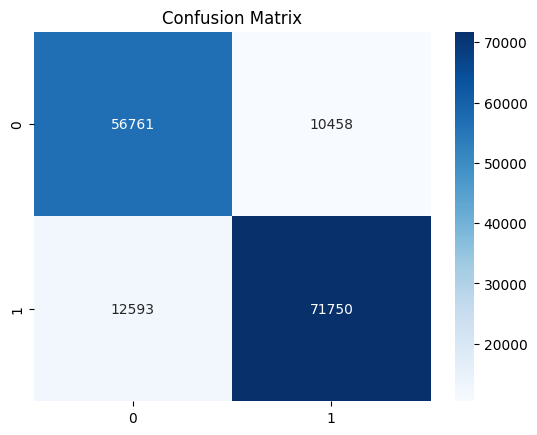

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, classification_report, confusion_matrix,
                            precision_recall_curve, roc_auc_score)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns




# HYPERPARAMETER TUNING

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


start_tune = time.time()
lr_tuned = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
lr_tuned.fit(X_train, y_train)
end_tune = time.time()

print("=== Best Parameters ===")
print(lr_tuned.best_params_)


best_lr = lr_tuned.best_estimator_
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]


print("\n=== Tuned Model ===")
print(f"Tuning Time (s): {end_tune - start_tune:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)



#cv_scores = cross_val_score(best_lr, X, y, cv=cv, scoring='f1')
#print(f"\nCV F1 Scores: {cv_scores}")
#print(f"Average CV F1: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")

# **Model Evaluation**

In [ ]:

metrics_nn = {
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "F1 Score": f1_score(y_test, y_pred_nn),
    "Training Time (s)": train_time,
    "Prediction Time (s)": predict_time
}
print(metrics_nn)
timed_results.append(metrics_nn)

# Convert updated results to DataFrame
updated_timed_results_df = pd.DataFrame(timed_results)

updated_timed_results_df

{'Model': 'Neural Network', 'Accuracy': 0.9918865784499055, 'Precision': 0.9950506307101676, 'Recall': 0.9906379011852444, 'F1 Score': 0.9928393628167398, 'Training Time (s)': 142.11117005348206, 'Prediction Time (s)': 6.0858118534088135}


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.896280,0.925687,0.888667,0.906799,1.425849,0.007610
1,Decision Tree,0.999788,0.999840,0.999787,0.999814,1.891303,0.011449
2,kNN,0.952749,0.995837,0.920629,0.956757,0.032360,252.686909
3,Random Forest,0.998185,0.999973,0.996830,0.998399,40.403679,1.106979
4,SVM,0.971025,0.993723,0.955001,0.973977,1290.536439,316.346623
5,Gradient Boosting,0.996650,0.999973,0.994127,0.997042,113.470742,0.251374
6,XGBoost,0.999849,0.999973,0.999760,0.999867,2.933453,0.220976
7,Neural Network,0.998314,0.999853,0.997177,0.998513,263.789684,0.371311
8,Neural Network,0.991887,0.995051,0.990638,0.992839,142.111170,6.085812


# **Feature Engineering using Shap**

100%|===================| 132138/132250 [16:53<00:00]       

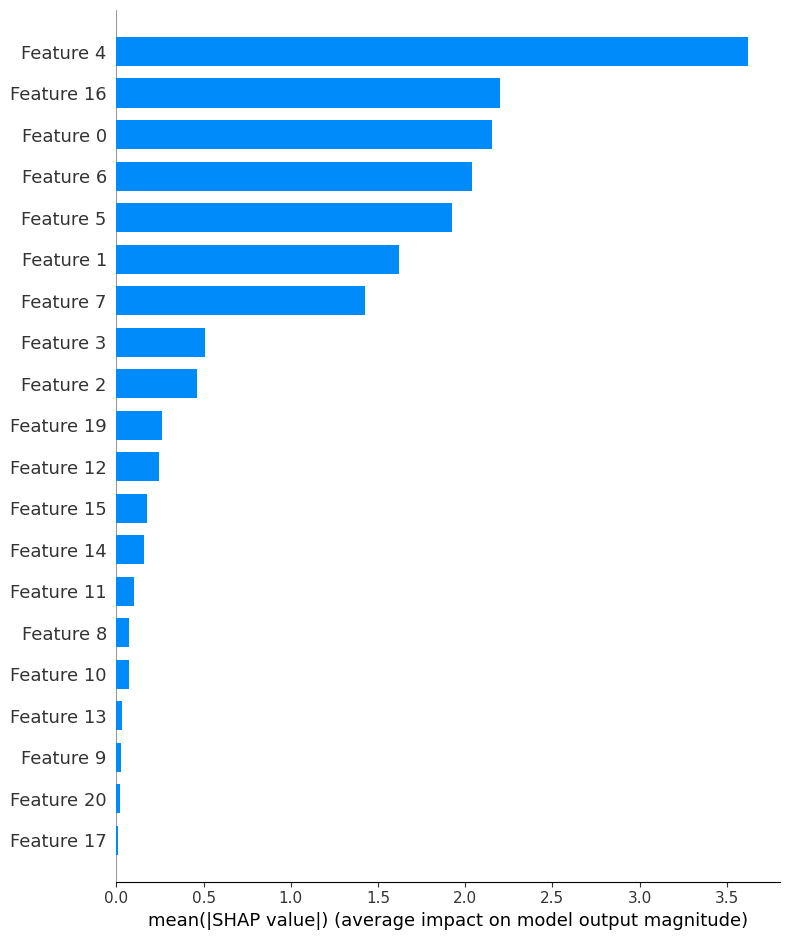

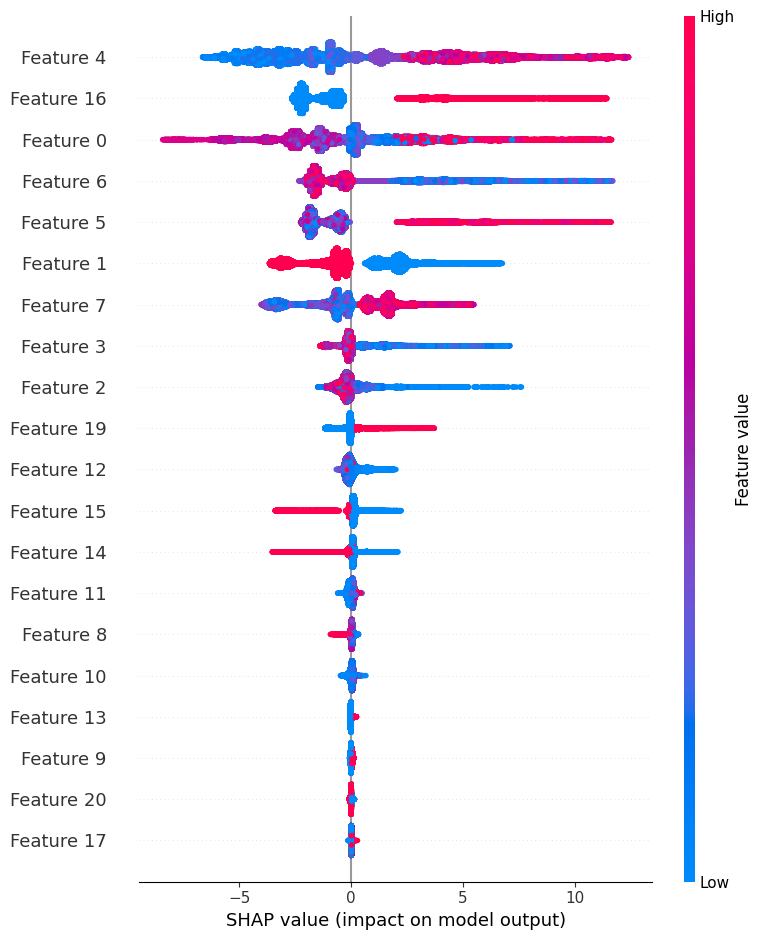

In [ ]:

explainer = shap.Explainer(optimized_model, X_test)
shap_values = explainer(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)


# **Streamlit appto test model**

In [ ]:
import joblib

# Save the trained model
joblib.dump(best_dt_model, 'best_dt_model.pkl')


['best_dt_model.pkl']

In [ ]:


from google.colab import files
files.download('best_dt_model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>